<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/19_Uncertainty_evaluation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q open_clip_torch ftfy regex tqdm pillow
!pip install -q transformers scikit-learn matplotlib seaborn
!pip install -q "numpy<2"


In [2]:
import os
import gc
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.covariance import EmpiricalCovariance

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import open_clip

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
class Config:
    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = os.path.join(BASE_DIR, "data/split")
    RESULTS_DIR = os.path.join(BASE_DIR, "results/uncertainty_benchmarks")

    BATCH_SIZE = 8
    NUM_WORKERS = 0
    SEED = 42

    # CLIP
    CLIP_MODEL = "ViT-B-32"
    CLIP_PRETRAINED = "openai"

    # BiomedCLIP (HF hub name for open_clip)
    BIOMEDCLIP_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

    VAL_SPLIT_RATIO = 0.2


os.makedirs(Config.RESULTS_DIR, exist_ok=True)

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def print_memory(prefix=""):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated(0)/1e9
        res = torch.cuda.memory_reserved(0)/1e9
        print(f"{prefix}GPU memory - alloc: {alloc:.2f} GB, reserved: {res:.2f} GB")


In [4]:
class MedicalImageDataset(Dataset):
    def __init__(self, split_dir: str, split_type: str = "test", transform=None):
        self.split_dir = split_dir
        self.split_type = split_type
        self.transform = transform

        self.samples = []
        self.class_to_idx = {}

        split_path = os.path.join(split_dir, split_type)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f"Split directory not found: {split_path}")

        class_folders = sorted(
            [d for d in os.listdir(split_path)
             if os.path.isdir(os.path.join(split_path, d))]
        )
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_folders)}

        for class_name in class_folders:
            class_dir = os.path.join(split_path, class_name)
            class_idx = self.class_to_idx[class_name]
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith((".png", ".jpg", ".jpeg", ".npy")):
                    img_path = os.path.join(class_dir, img_name)
                    self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        if img_path.endswith(".npy"):
            arr = np.load(img_path)
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            img = Image.fromarray(arr.astype("uint8"))
        else:
            img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img, label


def get_loader(split_dir: str,
               split_type: str = "test",
               batch_size: int = 8,
               num_workers: int = 0,
               transform=None) -> Tuple[DataLoader, MedicalImageDataset]:
    ds = MedicalImageDataset(split_dir, split_type=split_type, transform=transform)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
    )
    return loader, ds


In [5]:
def build_prompts(dataset_name: str, class_names: List[str]) -> List[str]:
    templates = {
        "MRI_tumor_binary_norm": [
            "a brain MRI scan showing a brain tumor",
            "a brain MRI scan showing a healthy brain without tumor",
        ],
        "MRI_tumor_multiclass_norm": [
            "a brain MRI scan showing a glioma tumor",
            "a brain MRI scan showing a meningioma tumor",
            "a brain MRI scan showing a healthy brain without tumor",
            "a brain MRI scan showing a pituitary tumor",
        ],
        "CT_stroke_binary_norm": [
            "a brain CT scan showing ischemic stroke",
            "a brain CT scan showing a normal brain without stroke",
        ],
        "MRI_ms_norm": [
            "a brain MRI scan showing multiple sclerosis lesions",
            "a brain MRI scan showing a normal brain without lesions",
        ],
    }

    if dataset_name in templates:
        # Ensure prompts match class order
        if len(templates[dataset_name]) == len(class_names):
            return templates[dataset_name]
        else:
            # Fallback if mismatch
            return [f"a medical image showing {cls}" for cls in class_names]
    else:
        return [f"a medical image showing {cls}" for cls in class_names]


In [20]:
class VLMWrapper:
    def __init__(self,
                 clip_model: str = "ViT-B-32",
                 pretrained: str = "openai",
                 use_biomedclip: bool = False):
        clear_memory()
        if use_biomedclip:
            from transformers import AutoTokenizer, AutoModel
            tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")
            model, self.preprocess = open_clip.create_model_from_pretrained(Config.BIOMEDCLIP_ID)
            self.tokenizer = tokenizer
            self.model = model.to(DEVICE)
            print("Loaded BiomedCLIP with PubMedBERT tokenizer.")
        else:
            self.model, _, self.preprocess = open_clip.create_model_and_transforms(
                clip_model, pretrained=pretrained
            )
            self.tokenizer = open_clip.get_tokenizer(clip_model)
            print(f"Loaded CLIP {clip_model} ({pretrained}).")

        self.model = self.model.to(DEVICE)
        self.model.eval()
        self.text_features = None
        self.class_prompts = None

    @torch.no_grad()
    def set_classes(self, prompts: List[str]):
        tokens = self.tokenizer(prompts).to(DEVICE)
        text_feat = self.model.encode_text(tokens)
        text_feat = F.normalize(text_feat, dim=-1)
        self.text_features = text_feat
        self.class_prompts = prompts
        clear_memory()

    @torch.no_grad()
    def encode_images(self, images: torch.Tensor) -> torch.Tensor:
        images = images.to(DEVICE)
        img_feat = self.model.encode_image(images)
        img_feat = F.normalize(img_feat, dim=-1)
        return img_feat

    @torch.no_grad()
    def logits_and_probs(self,
                         images: torch.Tensor,
                         logit_scale: float = 100.0) -> Tuple[torch.Tensor, torch.Tensor]:
        img_feat = self.encode_images(images)
        txt_feat = self.text_features.to(DEVICE)
        logits = logit_scale * img_feat @ txt_feat.T
        probs = F.softmax(logits, dim=-1)
        return logits.cpu(), probs.cpu()


In [7]:
def compute_ece(probs: torch.Tensor, labels: torch.Tensor, n_bins: int = 15) -> float:
    probs = probs.cpu()
    labels = labels.cpu()
    confidences, preds = torch.max(probs, dim=1)
    accuracies = preds.eq(labels)

    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i+1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.float().mean()
        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].float().mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += torch.abs(conf_in_bin - acc_in_bin) * prop_in_bin
    return ece.item()


def compute_error_auroc(probs: torch.Tensor,
                        labels: torch.Tensor,
                        uncertainty: torch.Tensor) -> float:
    preds = torch.argmax(probs, dim=1)
    errors = (preds != labels).cpu().numpy()
    u = uncertainty.cpu().numpy()
    if len(np.unique(errors)) < 2:
        return 0.5
    return roc_auc_score(errors, u)


def selective_prediction_curve(probs: torch.Tensor,
                               labels: torch.Tensor,
                               uncertainty: torch.Tensor,
                               n_points: int = 50) -> Tuple[np.ndarray, np.ndarray]:
    preds = torch.argmax(probs, dim=1)
    confidences, _ = torch.max(probs, dim=1)

    sorted_idx = torch.argsort(uncertainty)  # ascending: low unc first
    n = len(preds)

    coverages = []
    accuracies = []

    step = max(1, n // n_points)
    for i in range(step, n+1, step):
        idx = sorted_idx[:i]
        cov = i / n
        acc = (preds[idx] == labels[idx]).float().mean().item()
        coverages.append(cov)
        accuracies.append(acc)

    return np.array(coverages), np.array(accuracies)


In [8]:
class TemperatureScaling:
    def __init__(self):
        self.temperature = 1.0

    def find_optimal(self,
                     logits: torch.Tensor,
                     labels: torch.Tensor,
                     metric: str = "nll") -> float:
        logits = logits.cpu()
        labels = labels.cpu()
        temps = np.linspace(0.5, 3.0, 50)
        best_t, best_score = 1.0, float("inf")

        for t in temps:
            probs = F.softmax(logits / t, dim=1)
            if metric == "nll":
                nll = F.nll_loss(torch.log(probs + 1e-12), labels).item()
                score = nll
            elif metric == "ece":
                score = compute_ece(probs, labels)
            else:
                raise ValueError(metric)
            if score < best_score:
                best_score = score
                best_t = t
        self.temperature = best_t
        print(f"Optimal T={best_t:.3f} ({metric.upper()}={best_score:.4f})")
        return best_t

    def apply(self, logits: torch.Tensor) -> torch.Tensor:
        return F.softmax(logits / self.temperature, dim=1)


In [9]:
def logits_to_dirichlet(logits: torch.Tensor,
                        temperature: float = 1.0) -> torch.Tensor:
    logits = logits / temperature
    evidence = F.softplus(logits)
    alpha = evidence + 1.0
    return alpha


def dirichlet_uncertainty(alpha: torch.Tensor) -> Dict[str, torch.Tensor]:
    S = alpha.sum(dim=-1, keepdim=True)
    probs = alpha / S
    total_unc = 1.0 / S.squeeze(-1)
    var = (alpha * (S - alpha)) / (S**2 * (S + 1.0))
    aleatoric = var.sum(dim=-1)
    epistemic = total_unc
    return {
        "probs": probs,
        "total_uncertainty": total_unc,
        "aleatoric": aleatoric,
        "epistemic": epistemic,
        "evidence": S.squeeze(-1),
    }


In [18]:
class FeatureDensityEstimator:
    def __init__(self):
        self.class_means = None
        self.cov_inv = None

    @torch.no_grad()
    def fit(self, vlm: VLMWrapper, loader: DataLoader, num_classes: int):
        feats = []
        labels = []
        for imgs, y in tqdm(loader, desc="DDU calib"):
            f = vlm.encode_images(imgs).cpu()
            feats.append(f)
            labels.append(y.clone())
        feats = torch.cat(feats, dim=0).numpy()
        labels = torch.cat(labels, dim=0).numpy()

        d = feats.shape[1]
        means = np.zeros((num_classes, d), dtype=np.float32)
        for k in range(num_classes):
            cls_feats = feats[labels == k]
            means[k] = cls_feats.mean(axis=0)

        cov = EmpiricalCovariance()
        cov.fit(feats)
        cov_inv = cov.precision_.astype(np.float32)

        self.class_means = torch.from_numpy(means)
        self.cov_inv = torch.from_numpy(cov_inv)

    @torch.no_grad()
    def epistemic_uncertainty(self, vlm: VLMWrapper, imgs: torch.Tensor) -> torch.Tensor:
        f = vlm.encode_images(imgs).cpu()  # [B, D]
        means = self.class_means            # [K, D]
        cov_inv = self.cov_inv             # [D, D]

        diff = f.unsqueeze(1) - means.unsqueeze(0)     # [B, K, D]
        tmp = torch.matmul(diff, cov_inv)              # [B, K, D]
        d2 = (tmp * diff).sum(dim=-1)                  # [B, K]
        min_d2, _ = d2.min(dim=-1)
        return min_d2  # larger = more uncertain


In [11]:
def nonconformity_scores(probs: torch.Tensor,
                         labels: torch.Tensor) -> torch.Tensor:
    p_true = probs[torch.arange(len(labels)), labels]
    return 1.0 - p_true


def fit_conformal_threshold(probs: torch.Tensor,
                            labels: torch.Tensor,
                            alpha: float = 0.1) -> float:
    scores = nonconformity_scores(probs, labels).numpy()
    n = len(scores)
    q_index = int(np.ceil((n + 1) * (1 - alpha))) - 1
    q_index = min(max(q_index, 0), n - 1)
    return float(np.partition(scores, q_index)[q_index])


def conformal_sets(probs: torch.Tensor,
                   threshold: float) -> List[List[int]]:
    sets = []
    for p in probs:
        s = 1.0 - p
        in_set = (s <= threshold).nonzero(as_tuple=True)[0].tolist()
        sets.append(in_set)
    return sets


def evaluate_conformal(sets: List[List[int]],
                       labels: torch.Tensor) -> Dict[str, float]:
    labels_np = labels.numpy()
    cover = np.mean([labels_np[i] in sets[i] for i in range(len(labels_np))])
    sizes = np.array([len(s) for s in sets])
    return {"coverage": float(cover), "avg_size": float(sizes.mean())}


In [12]:
def tta_predict(vlm: VLMWrapper,
                images: torch.Tensor,
                n_augs: int = 4,
                logit_scale: float = 100.0) -> Tuple[torch.Tensor, torch.Tensor]:
    all_probs = []
    all_logits = []

    def aug(x):
        angle = np.random.uniform(-10, 10)
        x = transforms.functional.rotate(x, angle)
        x = transforms.functional.adjust_brightness(x, np.random.uniform(0.9, 1.1))
        x = transforms.functional.adjust_contrast(x, np.random.uniform(0.9, 1.1))
        return x

    # original
    logits, probs = vlm.logits_and_probs(images, logit_scale)
    all_logits.append(logits)
    all_probs.append(probs)

    for _ in range(n_augs - 1):
        imgs_aug = aug(images)
        logits, probs = vlm.logits_and_probs(imgs_aug, logit_scale)
        all_logits.append(logits)
        all_probs.append(probs)

    all_probs = torch.stack(all_probs, dim=0)   # [A, B, K]
    all_logits = torch.stack(all_logits, dim=0)

    mean_probs = all_probs.mean(dim=0)
    var_probs = all_probs.var(dim=0).mean(dim=-1)  # [B]
    entropy = -(mean_probs * torch.log(mean_probs + 1e-12)).sum(dim=-1)
    uncertainty = entropy + var_probs
    return all_logits.mean(dim=0), mean_probs, uncertainty


In [13]:
def evaluate_model(dataset_name: str,
                   use_biomedclip: bool = False,
                   use_temp_scaling: bool = True) -> pd.DataFrame:
    clear_memory()
    print("="*80)
    print(f"Dataset: {dataset_name} | Model: {'BiomedCLIP' if use_biomedclip else 'CLIP'}")
    print("="*80)

    split_dir = os.path.join(Config.SPLIT_DIR, dataset_name)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(split_dir)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    test_loader, test_ds = get_loader(
        split_dir, split_type="test",
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        transform=transform,
    )

    # Split into calib + test for temp scaling + DDU + conformal
    val_size = int(Config.VAL_SPLIT_RATIO * len(test_ds))
    test_size = len(test_ds) - val_size
    calib_ds, final_test_ds = random_split(
        test_ds, [val_size, test_size],
        generator=torch.Generator().manual_seed(Config.SEED)
    )

    calib_loader = DataLoader(
        calib_ds, batch_size=Config.BATCH_SIZE,
        shuffle=False, num_workers=Config.NUM_WORKERS
    )
    final_test_loader = DataLoader(
        final_test_ds, batch_size=Config.BATCH_SIZE,
        shuffle=False, num_workers=Config.NUM_WORKERS
    )

    print(f"Calib: {len(calib_ds)}, Test: {len(final_test_ds)}")

    # Model
    vlm = VLMWrapper(
        clip_model=Config.CLIP_MODEL,
        pretrained=Config.CLIP_PRETRAINED,
        use_biomedclip=use_biomedclip,
    )
    class_names = list(test_ds.class_to_idx.keys())
    prompts = build_prompts(dataset_name, class_names)
    vlm.set_classes(prompts)
    num_classes = len(class_names)

    # Collect calib logits/probs/labels
    calib_logits_list, calib_probs_list, calib_labels_list = [], [], []
    for imgs, y in tqdm(calib_loader, desc="Calib (baseline)"):
        logits, probs = vlm.logits_and_probs(imgs)
        calib_logits_list.append(logits)
        calib_probs_list.append(probs)
        calib_labels_list.append(y)

    calib_logits = torch.cat(calib_logits_list)
    calib_probs = torch.cat(calib_probs_list)
    calib_labels = torch.cat(calib_labels_list)

    # Temperature scaling
    temp_scaler = None
    if use_temp_scaling:
        temp_scaler = TemperatureScaling()
        temp_scaler.find_optimal(calib_logits, calib_labels, metric="nll")

    # DDU fit
    fde = FeatureDensityEstimator()
    fde.fit(vlm, calib_loader, num_classes=num_classes)

    # Conformal threshold
    conf_threshold = fit_conformal_threshold(calib_probs, calib_labels, alpha=0.1)
    print(f"Conformal threshold (alpha=0.1): {conf_threshold:.4f}")

    # Test-time evaluation
    methods = {
        "baseline": {"probs": [], "logits": [], "unc": []},
        "dirichlet": {"probs": [], "logits": [], "unc": []},
        "ddu": {"probs": [], "logits": [], "unc": []},
        "tta": {"probs": [], "logits": [], "unc": []},
    }
    all_labels = []

    for imgs, y in tqdm(final_test_loader, desc="Test"):
        all_labels.append(y)
        # baseline
        logits, probs = vlm.logits_and_probs(imgs)
        entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=-1)

        methods["baseline"]["logits"].append(logits)
        methods["baseline"]["probs"].append(probs)
        methods["baseline"]["unc"].append(entropy)

        # Dirichlet
        alpha = logits_to_dirichlet(logits)
        d_out = dirichlet_uncertainty(alpha)
        methods["dirichlet"]["logits"].append(logits)
        methods["dirichlet"]["probs"].append(d_out["probs"])
        methods["dirichlet"]["unc"].append(d_out["total_uncertainty"])

        # DDU
        ddu_unc = fde.epistemic_uncertainty(vlm, imgs)
        methods["ddu"]["logits"].append(logits)
        methods["ddu"]["probs"].append(probs)  # keep probs for ECE
        methods["ddu"]["unc"].append(ddu_unc)

        # TTA
        tta_logits, tta_probs, tta_unc = tta_predict(vlm, imgs, n_augs=4)
        methods["tta"]["logits"].append(tta_logits)
        methods["tta"]["probs"].append(tta_probs)
        methods["tta"]["unc"].append(tta_unc)

    all_labels = torch.cat(all_labels)

    # Aggregate
    for m in methods.keys():
        methods[m]["logits"] = torch.cat(methods[m]["logits"])
        methods[m]["probs"] = torch.cat(methods[m]["probs"])
        methods[m]["unc"] = torch.cat(methods[m]["unc"])

    # Conformal on baseline
    base_sets = conformal_sets(methods["baseline"]["probs"], conf_threshold)
    conf_stats = evaluate_conformal(base_sets, all_labels)

    # Metrics dataframe
    rows = []
    for mname, res in methods.items():
        probs = res["probs"]
        logits = res["logits"]
        unc = res["unc"]

        if temp_scaler is not None:
            probs_cal = temp_scaler.apply(logits)
        else:
            probs_cal = probs

        preds = torch.argmax(probs_cal, dim=1)
        acc = (preds == all_labels).float().mean().item()
        ece = compute_ece(probs_cal, all_labels)
        au = compute_error_auroc(probs_cal, all_labels, unc)
        rows.append({
            "dataset": dataset_name,
            "model": "BiomedCLIP" if use_biomedclip else "CLIP",
            "method": mname,
            "accuracy": acc,
            "ece": ece,
            "error_auroc": au,
        })

    df = pd.DataFrame(rows)
    print("\nMetrics:\n", df)

    # Save CSV
    out_csv = os.path.join(
        Config.RESULTS_DIR,
        f"{dataset_name}_{'biomedclip' if use_biomedclip else 'clip'}_metrics.csv"
    )
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    # Quick calibration plot
    plt.figure(figsize=(6, 5))
    for mname, res in methods.items():
        probs = res["probs"]
        pmax, preds = torch.max(probs, dim=1)
        accs = preds.eq(all_labels)
        n_bins = 15
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
        bin_acc = []
        bin_conf = []
        for i in range(n_bins):
            mask = (pmax > bin_boundaries[i]) & (pmax <= bin_boundaries[i+1])
            if mask.sum() > 0:
                bin_acc.append(accs[mask].float().mean().item())
                bin_conf.append(pmax[mask].mean().item())
            else:
                bin_acc.append(0.0)
                bin_conf.append(bin_centers[i])
        plt.plot(bin_conf, bin_acc, marker="o", label=mname)
    plt.plot([0, 1], [0, 1], "k--", label="perfect")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Calibration - {dataset_name}")
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(
        Config.RESULTS_DIR,
        f"{dataset_name}_{'biomedclip' if use_biomedclip else 'clip'}_calibration.png"
    )
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved:", fig_path)

    print("Conformal (baseline) stats:", conf_stats)
    return df


Dataset: MRI_tumor_binary_norm | Model: CLIP
Calib: 90, Test: 360


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded CLIP ViT-B-32 (openai).


Calib (baseline): 100%|██████████| 12/12 [00:18<00:00,  1.57s/it]


Optimal T=3.000 (NLL=0.7481)


DDU calib: 100%|██████████| 12/12 [00:16<00:00,  1.37s/it]


Conformal threshold (alpha=0.1): 0.7766


Test: 100%|██████████| 45/45 [06:32<00:00,  8.73s/it]



Metrics:
                  dataset model     method  accuracy       ece  error_auroc
0  MRI_tumor_binary_norm  CLIP   baseline  0.491667  0.206183     0.230635
1  MRI_tumor_binary_norm  CLIP  dirichlet  0.491667  0.206183     0.551480
2  MRI_tumor_binary_norm  CLIP        ddu  0.491667  0.206183     0.588775
3  MRI_tumor_binary_norm  CLIP        tta  0.405556  0.129759     0.305499
Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_tumor_binary_norm_clip_metrics.csv


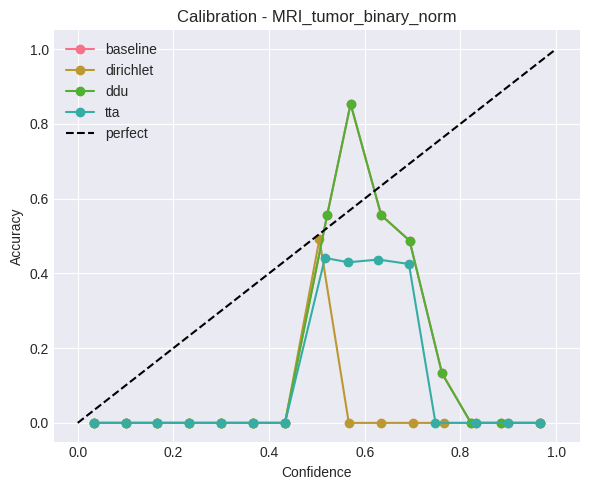

Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_tumor_binary_norm_clip_calibration.png
Conformal (baseline) stats: {'coverage': 0.9055555555555556, 'avg_size': 1.8916666666666666}
Dataset: MRI_tumor_multiclass_norm | Model: CLIP
Calib: 239, Test: 958


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded CLIP ViT-B-32 (openai).


Calib (baseline): 100%|██████████| 30/30 [01:55<00:00,  3.86s/it]


Optimal T=2.643 (NLL=2.2670)


DDU calib: 100%|██████████| 30/30 [00:44<00:00,  1.47s/it]


Conformal threshold (alpha=0.1): 0.9952


Test: 100%|██████████| 120/120 [22:04<00:00, 11.04s/it]



Metrics:
                      dataset model     method  accuracy       ece  error_auroc
0  MRI_tumor_multiclass_norm  CLIP   baseline  0.208768  0.053232     0.627935
1  MRI_tumor_multiclass_norm  CLIP  dirichlet  0.208768  0.053232     0.459037
2  MRI_tumor_multiclass_norm  CLIP        ddu  0.208768  0.053232     0.556227
3  MRI_tumor_multiclass_norm  CLIP        tta  0.209812  0.074913     0.521481
Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_tumor_multiclass_norm_clip_metrics.csv


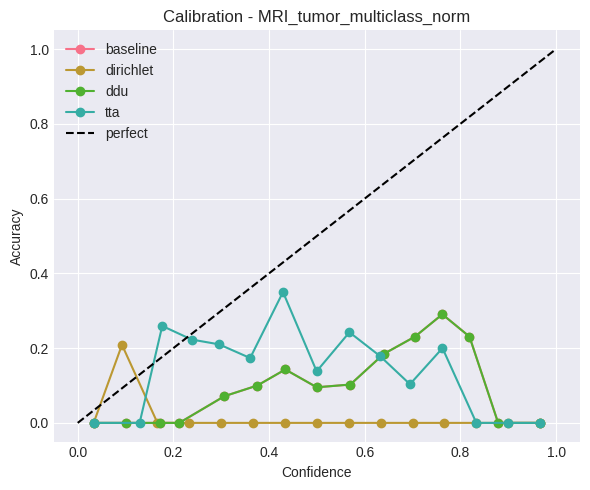

Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_tumor_multiclass_norm_clip_calibration.png
Conformal (baseline) stats: {'coverage': 0.8956158663883089, 'avg_size': 10.1419624217119}
Dataset: MRI_ms_norm | Model: CLIP
Calib: 117, Test: 469


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded CLIP ViT-B-32 (openai).


Calib (baseline): 100%|██████████| 15/15 [00:50<00:00,  3.34s/it]


Optimal T=3.000 (NLL=0.7938)


DDU calib: 100%|██████████| 15/15 [00:22<00:00,  1.47s/it]


Conformal threshold (alpha=0.1): 0.8674


Test: 100%|██████████| 59/59 [10:24<00:00, 10.59s/it]



Metrics:
        dataset model     method  accuracy       ece  error_auroc
0  MRI_ms_norm  CLIP   baseline  0.317697  0.293334     0.411703
1  MRI_ms_norm  CLIP  dirichlet  0.317697  0.293334     0.464083
2  MRI_ms_norm  CLIP        ddu  0.317697  0.293334     0.449822
3  MRI_ms_norm  CLIP        tta  0.586354  0.054126     0.448116
Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_ms_norm_clip_metrics.csv


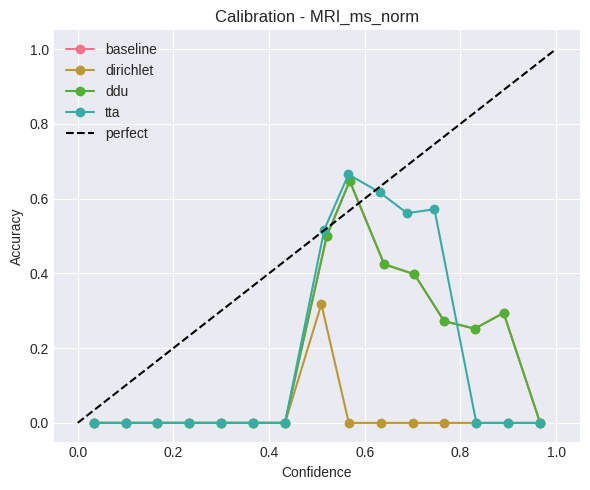

Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/MRI_ms_norm_clip_calibration.png
Conformal (baseline) stats: {'coverage': 0.9232409381663113, 'avg_size': 1.8912579957356077}
Dataset: CT_stroke_binary_norm | Model: CLIP
Calib: 199, Test: 800


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded CLIP ViT-B-32 (openai).


Calib (baseline): 100%|██████████| 25/25 [01:16<00:00,  3.07s/it]


Optimal T=3.000 (NLL=0.7108)


DDU calib: 100%|██████████| 25/25 [00:37<00:00,  1.51s/it]


Conformal threshold (alpha=0.1): 0.6915


Test: 100%|██████████| 100/100 [15:59<00:00,  9.59s/it]



Metrics:
                  dataset model     method  accuracy       ece  error_auroc
0  CT_stroke_binary_norm  CLIP   baseline    0.5025  0.080894     0.412692
1  CT_stroke_binary_norm  CLIP  dirichlet    0.5025  0.080894     0.427411
2  CT_stroke_binary_norm  CLIP        ddu    0.5025  0.080894     0.666198
3  CT_stroke_binary_norm  CLIP        tta    0.3400  0.221555     0.377611
Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/CT_stroke_binary_norm_clip_metrics.csv


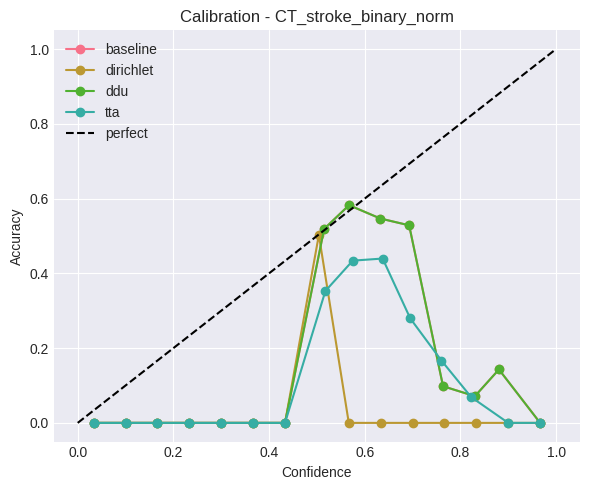

Saved: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/uncertainty_benchmarks/CT_stroke_binary_norm_clip_calibration.png
Conformal (baseline) stats: {'coverage': 0.87, 'avg_size': 1.82125}


,dataset,model,method,accuracy,ece,error_auroc
0,MRI_tumor_binary_norm,CLIP,baseline,0.491667,0.206183,0.230635
1,MRI_tumor_binary_norm,CLIP,dirichlet,0.491667,0.206183,0.551480
2,MRI_tumor_binary_norm,CLIP,ddu,0.491667,0.206183,0.588775
3,MRI_tumor_binary_norm,CLIP,tta,0.405556,0.129759,0.305499
4,MRI_tumor_multiclass_norm,CLIP,baseline,0.208768,0.053232,0.627935
5,MRI_tumor_multiclass_norm,CLIP,dirichlet,0.208768,0.053232,0.459037
6,MRI_tumor_multiclass_norm,CLIP,ddu,0.208768,0.053232,0.556227
7,MRI_tumor_multiclass_norm,CLIP,tta,0.209812,0.074913,0.521481
8,MRI_ms_norm,CLIP,baseline,0.317697,0.293334,0.411703
9,MRI_ms_norm,CLIP,dirichlet,0.317697,0.293334,0.464083


In [22]:
datasets = [
    "MRI_tumor_binary_norm",
    "MRI_tumor_multiclass_norm",
    "MRI_ms_norm",
    "CT_stroke_binary_norm",
]

all_results = []
for ds in datasets:
    df_clip = evaluate_model(ds, use_biomedclip=False)
    all_results.append(df_clip)

final_df = pd.concat(all_results, ignore_index=True)
final_df
